In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

In [2]:
# Load phyloP data
phyloP = pd.read_csv('../../../results/SV_effect/outputs/Ath_Simulated_DEL_Len_1-50_withPhyloP.tsv', sep='\t')
phyloP = phyloP.drop('mean_pcv2_large', axis=1)

In [3]:
def load_and_process_pcv2_single_shift(size, shift):
    """Load pcv2 file for a single shift value"""
    filename = f'../../../results/SV_effect/outputs/Ath_Simulated_DEL_Len_1-50_pcv2-{size}-2nd_shift_{shift}.tsv'
    
    df = pd.read_csv(filename, sep='\t')
    return df.iloc[:, 11:21].mean(axis=1)

def load_and_process_model_multiple_shifts(model, shift_values):
    """Load model files for multiple shifts and calculate mean scores"""
    dfs = []
    for shift in shift_values:
        if model.startswith('pcv2_'):
            size = model.split('_')[1]
            filename = f'../../../results/SV_effect/outputs/Ath_Simulated_DEL_Len_1-50_pcv2-{size}-2nd_shift_{shift}.tsv'
        else:
            # For evo2, gpn, pcv1
            filename = f'../../../results/SV_effect/outputs/Ath_Simulated_DEL_Len_1-50_{model}_shift_{shift}.tsv'
        
        df = pd.read_csv(filename, sep='\t')
        dfs.append(df.iloc[:, 11:21].mean(axis=1))
    
    return sum(dfs) / len(dfs)

In [4]:
shift_combinations = [
    [0],
    [0, 5], 
    [0, 5, 10],
    [0, 5, 10, 15],
    [0, 5, 10, 15, 20]
]
sizes = ['large', 'medium', 'small']

In [5]:
results = {}
relevant_mask = (phyloP['meanPhyloP'] > 1) | (phyloP['meanPhyloP'] < 0)
filtered_true_labels = np.where(phyloP['meanPhyloP'][relevant_mask] > 1, 1, 0)

# Define all models
all_models = ['pcv2_large', 'pcv2_medium', 'pcv2_small', 'Evo2', 'GPN', 'pcv1']

for i, shifts in enumerate(shift_combinations):
    shift_label = str(shifts)
    shift_results = {}
    
    # Process all models
    for model in all_models:
        print(f'Processing {model} with shifts {shifts}...')
        model_scores = load_and_process_model_multiple_shifts(model, shifts)
        filtered_scores = model_scores[relevant_mask] * -1
        ap_value = average_precision_score(filtered_true_labels, filtered_scores)
        shift_results[model] = ap_value
    
    results[shift_label] = shift_results

Processing pcv2_large with shifts [0]...
Processing pcv2_medium with shifts [0]...
Processing pcv2_small with shifts [0]...
Processing Evo2 with shifts [0]...
Processing GPN with shifts [0]...
Processing pcv1 with shifts [0]...
Processing pcv2_large with shifts [0, 5]...
Processing pcv2_medium with shifts [0, 5]...
Processing pcv2_small with shifts [0, 5]...
Processing Evo2 with shifts [0, 5]...
Processing GPN with shifts [0, 5]...
Processing pcv1 with shifts [0, 5]...
Processing pcv2_large with shifts [0, 5, 10]...
Processing pcv2_medium with shifts [0, 5, 10]...
Processing pcv2_small with shifts [0, 5, 10]...
Processing Evo2 with shifts [0, 5, 10]...
Processing GPN with shifts [0, 5, 10]...
Processing pcv1 with shifts [0, 5, 10]...
Processing pcv2_large with shifts [0, 5, 10, 15]...
Processing pcv2_medium with shifts [0, 5, 10, 15]...
Processing pcv2_small with shifts [0, 5, 10, 15]...
Processing Evo2 with shifts [0, 5, 10, 15]...
Processing GPN with shifts [0, 5, 10, 15]...
Processi

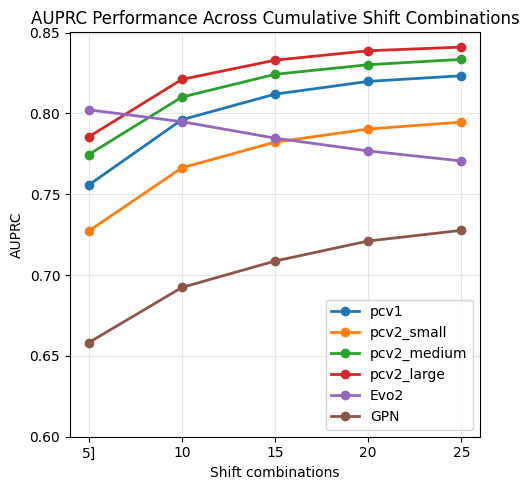

In [6]:
# Convert to DataFrame for easier plotting
results_df = pd.DataFrame(results).T
fig, ax = plt.subplots(figsize=(5, 5))

# Create x-axis labels for shift combinations
x_labels = ['5]', '10', '15', '20', '25']
x = np.arange(len(x_labels))

# Plot lines for each model
models = ['pcv1', 'pcv2_small', 'pcv2_medium', 'pcv2_large', 'Evo2', 'GPN']

# colors = ['#1f77b466', '#6baed6', '#1f77b4b3', '#1f77b4ff',  '#808080','#999999', '#d3d3d3']

for i, model in enumerate(models):
    ax.plot(x, results_df[model], 'o-', label=model,
            linewidth=2, markersize=6)

# Customize plot
ax.set_xlabel('Shift combinations')
ax.set_ylabel('AUPRC')
ax.set_title('AUPRC Performance Across Cumulative Shift Combinations')
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0.6)  # Adjust based on your data range

plt.tight_layout()
plt.savefig('AUPRC_versus_flanking_regions.pdf', format='pdf', bbox_inches='tight')
plt.show()